In [1]:
# Plot MVPA Evidence

import sys
import os
import pandas as pd
import numpy as np
import glob
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D



In [2]:
# initialize values needed for plotting
hue = {'maintain': '#6DAE45', 'track': '#0A5AF0', 'suppress': '#F0180A', 'breath': '#F08B0A'}
tr = 0.46

template_events = {
    "Onset": [0, 2.6, 6, 10],
    "Duration": [2.6, 3.4,2 ,4 ],
    "Event":["item N", "operation", "fixation", "item N+1"]
}



In [3]:

def _plot_mvpa_evidence_core(all_results, trial_type, title=""):
    
    # by default always plot as a confusion matrix (classifier categories x test categories)
    classifier_categories = [c.replace("evidence_","") for c in all_results.columns if "evidence_" in c]
    n_plots = len(classifier_categories)
    # by default, plot the classifier evidence -- matching trial type
    fig, axes = plt.subplots(n_plots, n_plots, figsize=(14, 10), sharey=True)

    # Big main header
    fig.suptitle(title, fontsize=22, fontweight='bold', y=0.995)
    
    # (classifier categories x test categories)
    
    # start by getting global min and max for y-scale 
    evidence_cols = all_results.filter(like="evidence")
    global_y_min = evidence_cols.min().min()
    global_y_max = evidence_cols.max().max() if  evidence_cols.max().max() > 1.1 else 1.1


    for idx, t in enumerate(classifier_categories):
        for idy, c in enumerate(classifier_categories):
            ax = axes[idx,idy]
            
            # select only the data for the particular classifier evidence and trial type
            subset_data = clean_results.drop(columns=[l for l in clean_results.columns if l.startswith("evidence") and c not in l])
            subset_data = subset_data[
                (subset_data[trial_type] == t)
            ]
            
            # make sure there is only one evidence condition remaining in the dataframe
            evidence_cols = subset_data.filter(like="evidence").columns

            if len(evidence_cols) != 1:
                raise ValueError(f"Expected exactly 1 evidence column, found {list(evidence_cols)}")

            subset_data.rename(columns={evidence_cols[0]: "evidence"}, inplace=True)
            
            # loop over hue ....
            for op, color in hue.items():
                plot_data = subset_data[
                    subset_data["operation"] == op
                ]
                _plot_evidence(ax, plot_data, tr, color)
            
            # set labels
            ax.set_ylabel(f"{c.capitalize()} Evidence for {t.capitalize()} Trials")
            if idx == 0:
                ax.set_title(f"{c.capitalize()} Classifier Evidence")

            # add event labels
            ax.set_ylim(global_y_min, global_y_max)
            _plot_key_events(ax, template_events)
    
    
    # Legend stays for operations (colors)
    legend_patches = [Patch(facecolor=color) for color in hue.values()]
    legend_labels = [op.capitalize() for op in hue.keys()]
    fig.legend(
        handles=legend_patches,
        labels=legend_labels,
        loc='upper center',
        ncol=4,
        frameon=False,
        bbox_to_anchor=(0.5, 0.955),
        title="Color = Operation"
    )
    
    
    # Leave room at top for header + legend
    plt.tight_layout(rect=[0, 0, 1, 0.90])
    plt.show()
    
    
    


def _plot_evidence(ax, data, tr, color='black', linestyle='solid'):

    agg_df = (
        data.groupby('window')
        .agg(
            mean_evi=('evidence', 'mean'),
            se_evi=('evidence', lambda x: x.std(ddof=1) / np.sqrt(len(x)))
        )
        .reset_index()
        .sort_values('window')
    )

    x = agg_df['window'] * tr
    y = agg_df['mean_evi']
    se = agg_df['se_evi']
    
    ax.plot(x, y, color=color, linestyle=linestyle, linewidth=2)
    ax.fill_between(x, y - se, y + se, color=color, alpha=0.3)
    ax.set_xlim(min(x), max(x))
    ax.set_xticks(np.arange(1, max(x) + 1, 2))
    ax.set_xticklabels([str(int(t)) for t in np.arange(1, max(x) + 1, 2)])
    ax.set_xlabel("Time (sec)")

    



def _plot_key_events(ax, template_events):
    
    # store limits
    y_min, y_max = ax.get_ylim()
    x_min, x_max = ax.get_xlim()
    
    # place y labels near plot bottom
    yloc = y_min + 0.05 * (y_max - y_min)
    
    df = pd.DataFrame(template_events)
    
    for row in df.itertuples(index=False):
        
        # add event label
        ax.text(
            row.Onset + row.Duration / 2,
            yloc,
            row.Event,
            ha='center',
            fontsize=9,
            fontweight='bold'
        )
        
        # add event boundary (if non-zero)
        if row.Onset != 0:
            ax.axvline(x=row.Onset, color='black', linestyle='-', linewidth=0.25)

    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)   # restore full range
    ax.grid(False)



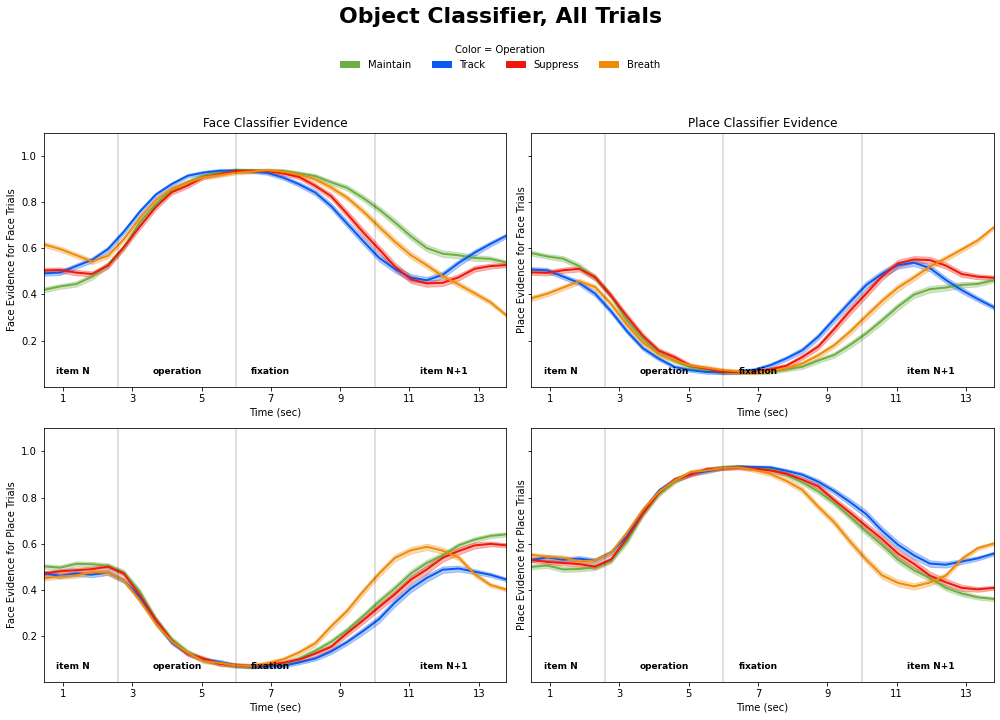

In [11]:
# load evidence files...
evidence_path = "/scratch/alpine/amhe4269/mvpa_code_debugging/vvs_object_classifier/*_decoding_results.csv"

all_results = pd.DataFrame()
for file in glob.glob(evidence_path):
    f = pd.read_csv(file)
    all_results = pd.concat([all_results, f], ignore_index = True)



# if there is a QA list to work from... check that here
subject_list = "<path/to/file>"
if os.path.isfile(subject_list):
    valid_subjects = pd.read_csv(subject_list)
else:
    valid_subjects = all_results["subject"].unique()

clean_results = all_results[all_results['subject'].isin(valid_subjects)]
clean_results = clean_results.rename(columns={'pul_vols_seq': 'window'})

_plot_mvpa_evidence_core(clean_results, trial_type = "clusterID", title = "Object Classifier, All Trials")

# also plot importance map and classifier accuracy (with k-fold??)


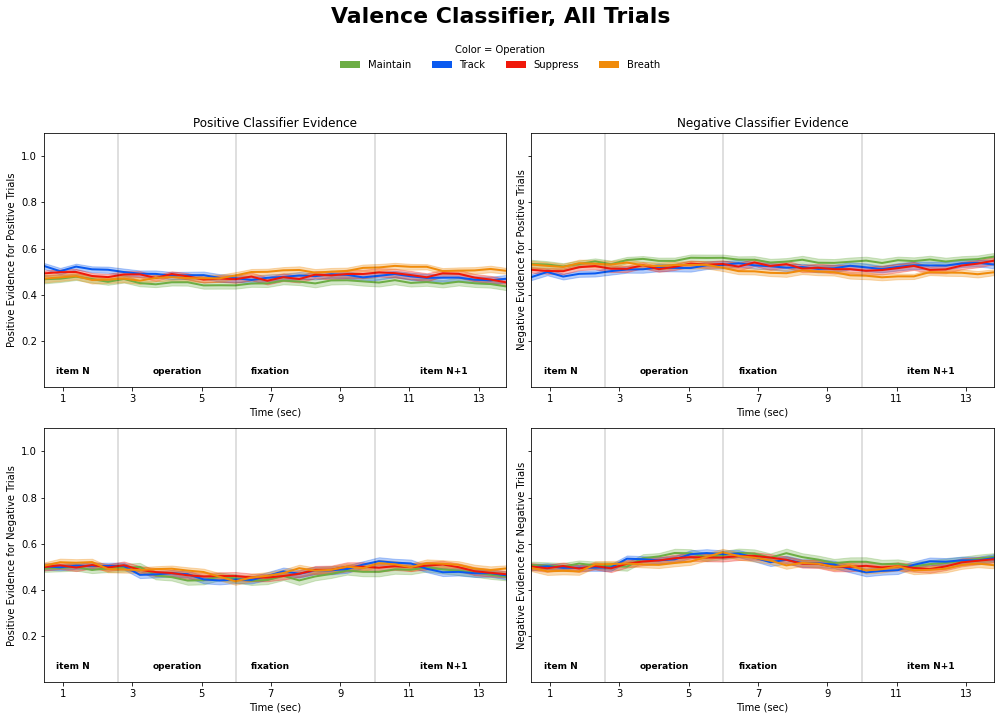

In [82]:
# load evidence files...
evidence_path = "/scratch/alpine/amhe4269/mvpa_code_debugging/final_mask_valence_classifier/*_results.csv"

all_results = pd.DataFrame()
for file in glob.glob(evidence_path):
    f = pd.read_csv(file)
    all_results = pd.concat([all_results, f], ignore_index = True)



# if there is a QA list to work from... check that here
subject_list = "<path/to/file>"
if os.path.isfile(subject_list):
    valid_subjects = pd.read_csv(subject_list)
else:
    valid_subjects = all_results["subject"].unique()

clean_results = all_results[all_results['subject'].isin(valid_subjects)]
clean_results = clean_results.rename(columns={'pul_vols_seq': 'window'})

_plot_mvpa_evidence_core(clean_results, trial_type = "valence", title = "Valence Classifier, All Trials")

# also plot importance map and classifier accuracy (with k-fold??)

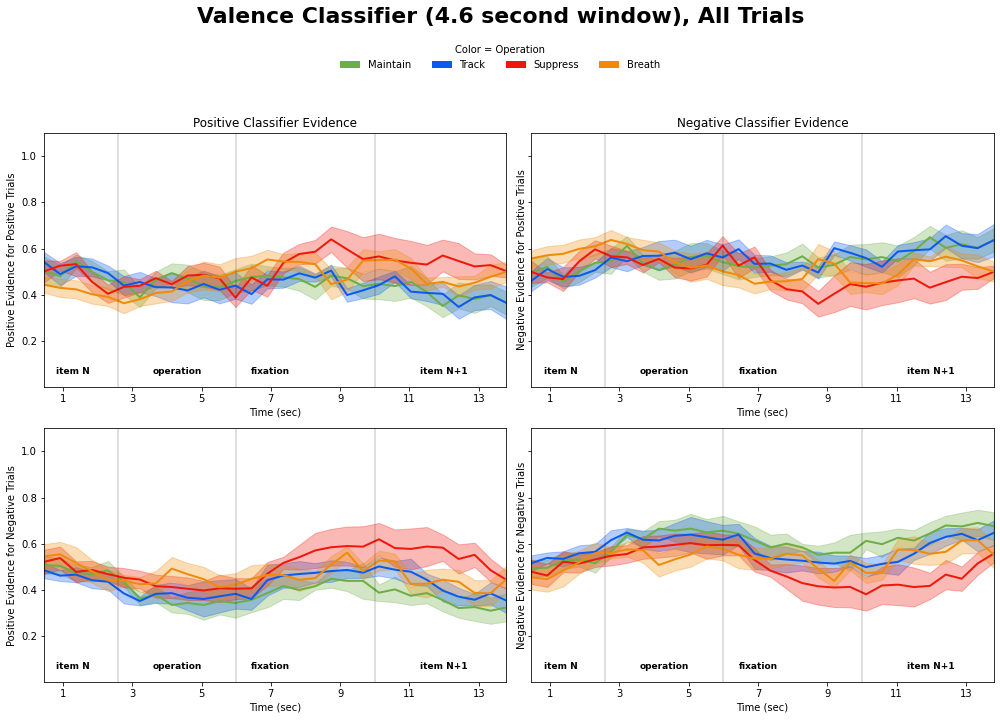

In [85]:
# load evidence files...
evidence_path = "/scratch/alpine/amhe4269/mvpa_code_debugging/final_mask_valence_classifier_short/*_results.csv"

all_results = pd.DataFrame()
for file in glob.glob(evidence_path):
    f = pd.read_csv(file)
    all_results = pd.concat([all_results, f], ignore_index = True)



# if there is a QA list to work from... check that here
subject_list = "<path/to/file>"
if os.path.isfile(subject_list):
    valid_subjects = pd.read_csv(subject_list)
else:
    valid_subjects = all_results["subject"].unique()

clean_results = all_results[all_results['subject'].isin(valid_subjects)]
clean_results = clean_results.rename(columns={'pul_vols_seq': 'window'})

_plot_mvpa_evidence_core(clean_results, trial_type = "valence", title = "Valence Classifier (4.6 second window), All Trials")

# also plot importance map and classifier accuracy (with k-fold??)